In [ ]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z
from temgym_core.gaussian import InterpolatedFields3D

jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [ ]:
tilt_0 = jnp.deg2rad(0)  # 0 degrees
tilt_45 = jnp.deg2rad(45)  # 45 degrees
tilt_180 = jnp.deg2rad(180)  # 180 degrees

fields_0, x_coords_0, y_coords_0, z_coords_0 = make_tilted_uniform_cube(
    tilt_x=tilt_0,
    V0=10.0,
    B0=1.0,
)
cube_0 = InterpolatedFields3D.from_array(fields_0, x_coords_0, y_coords_0, z_coords_0)

fields_45, x_coords_45, y_coords_45, z_coords_45 = make_tilted_uniform_cube(
    tilt_x=tilt_45,
    V0=10.0,
    B0=1.0,
)
cube_45 = InterpolatedFields3D.from_array(fields_45, x_coords_45, y_coords_45, z_coords_45)

fields_180, x_coords_180, y_coords_180, z_coords_180 = make_tilted_uniform_cube(
    tilt_x=tilt_180,
    V0=10.0,
    B0=1.0,
)
cube_180 = InterpolatedFields3D.from_array(fields_180, x_coords_180, y_coords_180, z_coords_180)

In [ ]:
voltage = 100e3  # in Volts
phi0 = project_phase_along_z(fields_0, z_coords_0, 100e3)
phi45 = project_phase_along_z(fields_45, z_coords_45, 100e3)
phi180 = project_phase_along_z(fields_180, z_coords_180, 100e3)
sample_2d_0 = jnp.exp(1j * phi0)
sample_2d_45 = jnp.exp(1j * phi45)
sample_2d_180 = jnp.exp(1j * phi180)


Text(0.5, 0.98, 'Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')

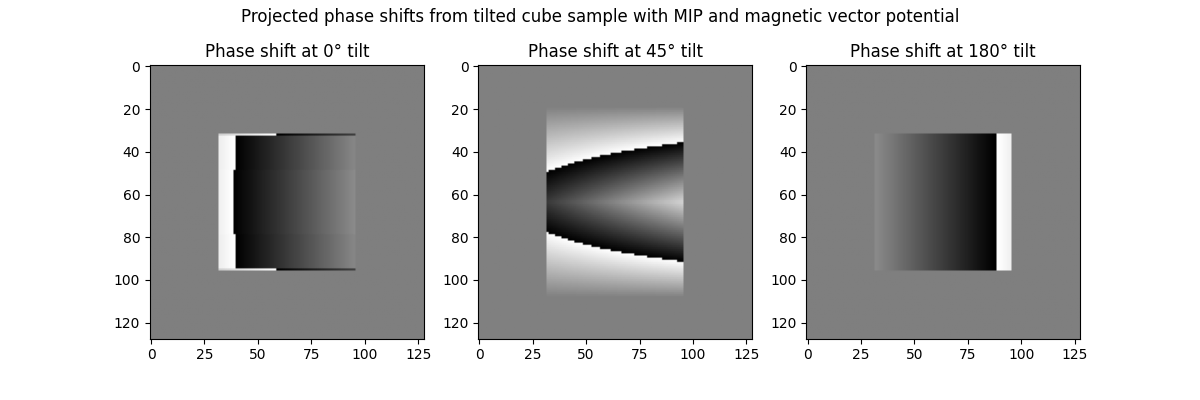

In [71]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(jnp.angle(sample_2d_0), cmap='gray')
axs[0].set_title('Phase shift at 0° tilt')
axs[1].imshow(jnp.angle(sample_2d_45), cmap='gray')
axs[1].set_title('Phase shift at 45° tilt')
axs[2].imshow(jnp.angle(sample_2d_180), cmap='gray')
axs[2].set_title('Phase shift at 180° tilt')
fig.suptitle('Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')